In [84]:
import gmsh

import numpy as np
from mpi4py import MPI

import dolfinx
import meshio
from dolfinx import mesh as dmesh
from dolfinx import *
from dolfinx.fem import  dirichletbc, locate_dofs_topological, Constant
from dolfinx.mesh import locate_entities_boundary
from dolfinx.io import XDMFFile
import ufl
from petsc4py import PETSc
from slepc4py import SLEPc

from dolfinx.fem.petsc import assemble_matrix, assemble_vector, apply_lifting, set_bc

# Visualization
import pyvista as pv
import pandas as pd

In [85]:
file ='/Users/straniero/Documents/Dphil/muon_collider/elements.csv'
df = pd.read_csv(file, index_col=0)
bore_radius = df.loc['Bore radius', 'pos']
Length = 37.47405725
Iris_a = df.loc['Iris A', 'pos']
Iris_b = df.loc['Iris B', 'pos']
Iris_center_y = df.loc['Iris center y', 'pos']
Iris_center_x = 0.0
iris_pos1_y = df.loc['iris_p1_y', 'pos']
iris_pos1_x = df.loc['iris_p1_x', 'pos']
iris_pos2_y = df.loc['iris_p2_y', 'pos']
iris_pos2_x = df.loc['iris_p2_x', 'pos']


Dome_A = df.loc['Dome A', 'pos']
Dome_B = df.loc['Dome B', 'pos']
Dome_center_x = Length/2
Dome_center_y = df.loc['Dome center y', 'pos']
dome_pos0_x = 12.62750856
dome_pos1_y = df.loc['dome_p1_y', 'pos']
dome_pos1_x = df.loc['dome_p1_x', 'pos']
dome_pos2_y = df.loc['dome_p2_y', 'pos']
dome_pos2_x = df.loc['dome_p2_x', 'pos']



iris_p1 = [iris_pos1_x + Iris_center_x, iris_pos1_y + Iris_center_y]
iris_p2 = [iris_pos2_x + Iris_center_x, iris_pos2_y + Iris_center_y]

dome_p0 = [Dome_center_x-dome_pos2_x, dome_pos2_y+Dome_center_y]
dome_p1 = [Dome_center_x,             Dome_center_y+dome_pos1_y]
dome_p2 = [Dome_center_x+dome_pos2_x, dome_pos2_y+Dome_center_y]


In [86]:
gmsh.initialize()
gmsh.option.setNumber("General.Terminal", 1)
gmsh.model.add("ell_cav")

p1 = gmsh.model.geo.addPoint(0, 0, 0)
p2 = gmsh.model.geo.addPoint(0, bore_radius, 0)
p3 = gmsh.model.geo.addPoint(iris_p2[0], iris_p2[1], 0)
p4 = gmsh.model.geo.addPoint(dome_p0[0], dome_p0[1], 0)
p5 = gmsh.model.geo.addPoint(dome_p1[0], dome_p1[1], 0)
p6 = gmsh.model.geo.addPoint(dome_p2[0], dome_p2[1], 0)
p7 = gmsh.model.geo.addPoint(Length-iris_pos2_x, iris_p2[1], 0)
p8 = gmsh.model.geo.addPoint(Length, bore_radius, 0)
p9 = gmsh.model.geo.addPoint(Length, 0, 0)

iris_center = gmsh.model.geo.addPoint(Iris_center_x, Iris_center_y, 0)
iris_maj = gmsh.model.geo.addPoint(Iris_center_x , Iris_center_y-1, 0)
iris_center2 = gmsh.model.geo.addPoint(Length , Iris_center_y, 0)
iris_maj2 = gmsh.model.geo.addPoint(Length , Iris_center_y-1, 0)
dome_center = gmsh.model.geo.addPoint(Dome_center_x, Dome_center_y, 0)
dome_maj = gmsh.model.geo.addPoint(Dome_center_x+1, Dome_center_y, 0)
#lines

l1 = gmsh.model.geo.addLine(p1, p2)
l2 = gmsh.model.geo.addEllipseArc(p2, iris_center, iris_maj, p3)
l3 = gmsh.model.geo.addLine(p3, p4)
l4 = gmsh.model.geo.addEllipseArc(p4, dome_center, dome_maj, p5)
l5 = gmsh.model.geo.addEllipseArc(p5, dome_center, dome_maj, p6)
l6 = gmsh.model.geo.addLine(p6, p7)
l7 = gmsh.model.geo.addEllipseArc(p7, iris_center2, iris_maj2, p8)
l8 = gmsh.model.geo.addLine(p8, p9)
l9 = gmsh.model.geo.addLine(p9, p1)

cl1 = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4, l5, l6, l7, l8, l9])
s1 = gmsh.model.geo.addPlaneSurface([cl1])

# Synchronize and create physical groups so dolfinx.gmshio can detect cell types
gmsh.model.geo.synchronize()
surf_tag = gmsh.model.addPhysicalGroup(2, [s1])
gmsh.model.setPhysicalName(2, surf_tag, "domain")
line_tags = [l1, l2, l3, l4, l5, l6, l7, l8, l9]
bnd_tag = gmsh.model.addPhysicalGroup(1, line_tags)
gmsh.model.setPhysicalName(1, bnd_tag, "boundary")

# Set mesh precision (adjust mesh_size for finer/coarser mesh)
mesh_size = 0.5  # decrease for finer mesh
gmsh.model.mesh.setSize(gmsh.model.getEntities(0), mesh_size)

gmsh.model.mesh.generate(2)
# Export directly to dolfinx mesh using gmshio
from dolfinx.io import gmshio
comm = MPI.COMM_WORLD
# The third argument is the root rank that created the gmsh model; use 0
dolfinx_mesh, cell_tags, facet_tags = gmshio.model_to_mesh(gmsh.model, comm, 0, gdim=2)

# Optionally save XDMF for later use
with XDMFFile(comm, "ellipse_mesh.xdmf", "w") as xdmf:
    xdmf.write_mesh(dolfinx_mesh)

# finalize gmsh
gmsh.finalize()

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Ellipse)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 40%] Meshing curve 4 (Ellipse)
Info    : [ 50%] Meshing curve 5 (Ellipse)
Info    : [ 60%] Meshing curve 6 (Line)
Info    : [ 70%] Meshing curve 7 (Ellipse)
Info    : [ 80%] Meshing curve 8 (Line)
Info    : [ 90%] Meshing curve 9 (Line)
Info    : Done meshing 1D (Wall 0.00244863s, CPU 0.003911s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.050209s, CPU 0.077586s)
Info    : 3811 nodes 7623 elements


In [87]:
# Solve axisymmetric Helmholtz eigenproblem: (d2/dr2 + (1/r) d/dr + d2/dz2) f = -k^2 f
# Weak form (axisymmetric): a(u,v) = \int r grad(u)·grad(v) dx, m(u,v) = \int r u v dx

import numpy as np
k=0.2

import ufl
from dolfinx import fem
from dolfinx.fem.petsc import assemble_matrix, assemble_vector, set_bc
from dolfinx.fem import dirichletbc, locate_dofs_topological
from dolfinx.mesh import locate_entities_boundary

# Use the dolfinx mesh created earlier
mesh_obj = dolfinx_mesh

# Construct FunctionSpace by first creating a UFL finite element

try:
    V = fem.functionspace(mesh_obj,("CG", 1))
except Exception:
    try:
        V = fem.FunctionSpace(mesh_obj, ("CG", 1))
    except Exception as e:
        raise RuntimeError("Failed to construct FunctionSpace: " + str(e))

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)
X = ufl.SpatialCoordinate(mesh_obj)
r = X[0]
a= (ufl.inner(ufl.grad(u), ufl.grad(v)) - (k**2) * u * v) * r * ufl.dx
a_form = fem.form(a)
#m_form = fem.form(ufl.inner(u, v) * r * ufl.dx)
f = Constant(mesh_obj, PETSc.ScalarType(1.0))                         #f_expr_value = 1.0           forcing (right-hand side) scalar value
L = f * v * r * ufl.dx




ld: warning: duplicate -rpath '/opt/anaconda3/envs/fenics-py312/lib' ignored
ld: warning: duplicate -rpath '/opt/anaconda3/envs/fenics-py312/lib' ignored


In [88]:
dofs_point = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[0], 1.0) & np.isclose(x[1], 3.0))
u_point = fem.Function(V)
u_point.x.array[:] = 0.0
u_point.x.array[dofs_point] = 2.0
bc_point = dirichletbc(u_point, dofs_point)

bcs = [bc_point]



In [89]:
A = assemble_matrix(a_form, bcs=bcs)
A.assemble()
b = assemble_vector(fem.form(L))
set_bc(b, bcs)

In [90]:
from dolfinx.fem.petsc import LinearProblem

# Wrap as LinearProblem for convenience (it will create PETSc objects and solve)
# create solution Function
u = fem.Function(V)

# Provide the UFL bilinear form `a` and linear form `L` (not assembled matrices)
problem = LinearProblem(a, L, bcs=bcs, petsc_options={
    # Helmholtz is indefinite — prefer gmres + ilu or gmres + asm/hypre AMG with right preconditioning
    "ksp_type": "gmres",
    "pc_type": "hypre",      # or "ilu"/"asm"/"gamg" depending on PETSc build
    "ksp_rtol": 1e-8
}, u=u)

uh = problem.solve()   # uh is the solution Function


# ---------------------------------------------------------------------
# 7) Postprocess: save to XDMF for ParaView or print a few diagnostics
# ---------------------------------------------------------------------
from dolfinx.io import XDMFFile

with XDMFFile(mesh_obj.comm, "solution_helmholtz.xdmf", "w") as xdmf:
    xdmf.write_mesh(mesh_obj)
    xdmf.write_function(uh)

if comm.rank == 0:
    print("Solve complete. Solution written to 'solution_helmholtz.xdmf'")

# Example: evaluate solution at a point (r0,z0) on rank 0
if comm.rank == 0:
    pt = np.array([0.1, 0.0], dtype=np.float64)  # (r,z)
    try:
        val = uh.eval(pt, np.array([0], dtype=np.int32))
        print(f"u({pt}) = {val}")
    except Exception as e:
        print("Evaluation at point failed (point might be outside domain):", e)

Solve complete. Solution written to 'solution_helmholtz.xdmf'
Evaluation at point failed (point might be outside domain): Coordinate(s) for Function evaluation must have length 3.


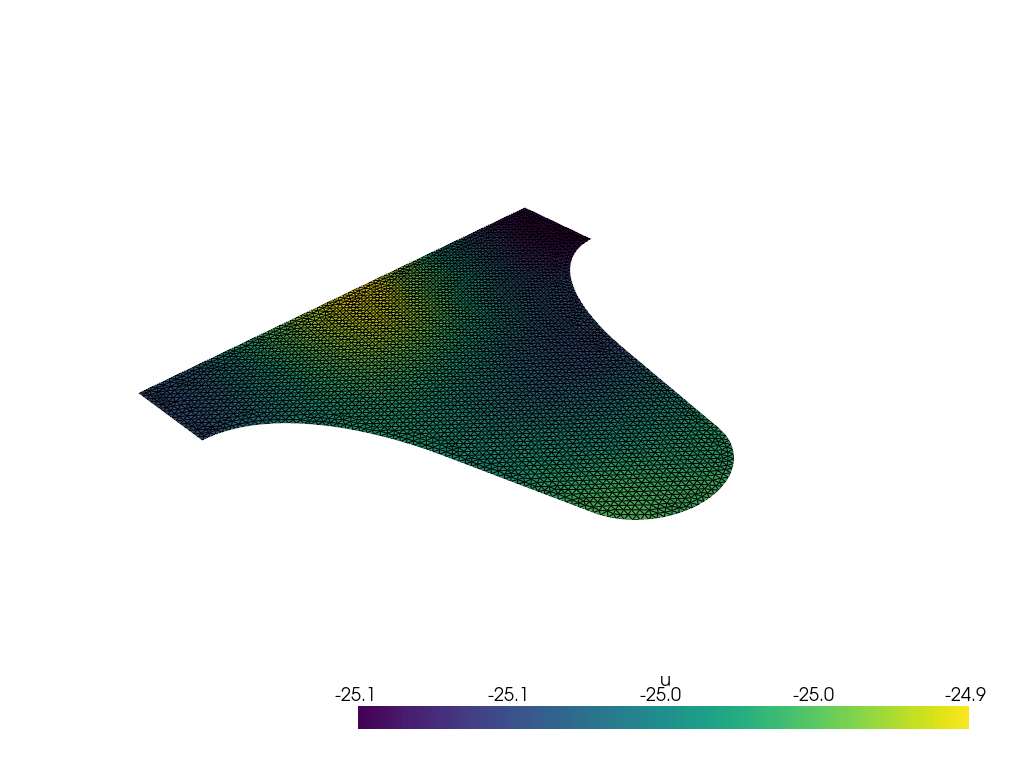

In [91]:
# Visualization with pyvista
sol_array = uh.x.array
# get coordinates (global)
coords = mesh_obj.geometry.x.copy()   # (num_vertices, gdim)
coords = np.array(coords)         # ensure numpy array
num_vertices_per_cell = mesh_obj.topology.dim + 1  # triangles -> 3
# get cell->vertex connectivity for triangles
top = mesh_obj.topology.connectivity(mesh_obj.topology.dim, 0)
conn = top.array.reshape((-1, num_vertices_per_cell))  # cells x num_vertices_per_cell
cells = conn.astype(np.int64)

# build pyvista cell array format
n_cells = cells.shape[0]
cell_types = np.full(n_cells, pv.CellType.TRIANGLE, dtype=np.uint8)
cells_pv = np.hstack([np.full((n_cells, 1), num_vertices_per_cell, dtype=np.int64), cells]).flatten()

grid = pv.UnstructuredGrid(cells_pv, cell_types, coords)
# attach solution at nodal points if number of points matches
if coords.shape[0] == sol_array.shape[0]:
    grid["u"] = sol_array
else:
    # might be cell-wise: attach cell data
    if sol_array.shape[0] == n_cells:
        grid.cell_data["u"] = sol_array
    else:
        print("Mismatch between dofs and points — skip attaching data")

p = pv.Plotter(notebook=True)
p.add_mesh(grid, scalars="u", show_edges=True)
p.add_scalar_bar("u")
p.show()